# Task 3.2: Failure Mode of the WL Subtree Kernel

**Paper**: Weisfeiler-Lehman Graph Kernels (Shervashidze et al., JMLR 2011)

**Student**: Meghavi (Roll: 230044)

## Scenario: Regular Graphs with Uniform Node Labels

We construct a classification task where the WL subtree kernel **fundamentally fails** due to the expressivity limitation of the 1-dimensional WL test.

### Setup

- **Class 0**: 3-regular graphs on 8 nodes (all nodes have degree 3, all nodes have label 0)
- **Class 1**: 3-regular graphs on 10 nodes (all nodes have degree 3, all nodes have label 0)

### Why This Fails

In a $k$-regular graph where all nodes share the same label:
1. **Iteration 0**: All nodes have label 0 → histogram = {0: n}
2. **Iteration 1**: Every node collects the same multiset of neighbor labels (three copies of label 0). With the prefix, the string is "0_0_0_0" for ALL nodes → all get the same compressed label.
3. **Iteration 2+**: Same pattern repeats — all nodes again have identical neighborhoods → same compressed label.

Result: All graphs of the **same size** produce **identical feature vectors**, making classification based on structure impossible. The kernel can only distinguish graphs of different sizes (different total label counts).

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import os
from collections import defaultdict
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score

SEED = 42
np.random.seed(SEED)
results_dir = os.path.join(os.path.dirname(os.path.abspath('.')), 'partB', 'results')

## Generate Regular Graphs with Uniform Labels

We generate distinct 3-regular graphs on the **same number of nodes** (8 nodes) for both classes. We use different random seeds to get structurally different regular graphs, but assign the same uniform label (0) to all nodes.

In [2]:
def generate_regular_graphs(n_graphs, n_nodes, degree, label, seed_start):
    """Generate random regular graphs with uniform labels."""
    graphs = []
    for i in range(n_graphs):
        G = nx.random_regular_graph(degree, n_nodes, seed=seed_start + i)
        node_labels = {v: label for v in G.nodes()}
        nx.set_node_attributes(G, node_labels, 'label')
        graphs.append(G)
    return graphs

# Class 0: 3-regular on 8 nodes
class0_reg = generate_regular_graphs(50, 8, 3, 0, seed_start=0)
# Class 1: 3-regular on 8 nodes (different random structures)
class1_reg = generate_regular_graphs(50, 8, 3, 0, seed_start=1000)

all_reg_graphs = class0_reg + class1_reg
y_reg = np.array([0]*50 + [1]*50)

print(f"Class 0: {len(class0_reg)} 3-regular graphs on 8 nodes")
print(f"Class 1: {len(class1_reg)} 3-regular graphs on 8 nodes")
print(f"All nodes have uniform label 0, all have degree 3")

# Verify regularity
for G in all_reg_graphs[:5]:
    degrees = [d for _, d in G.degree()]
    assert all(d == 3 for d in degrees), "Not 3-regular!"

Class 0: 50 3-regular graphs on 8 nodes
Class 1: 50 3-regular graphs on 8 nodes
All nodes have uniform label 0, all have degree 3


## Visualize Example Graphs

Despite having the same degree and labels, these graphs can be structurally different (non-isomorphic).

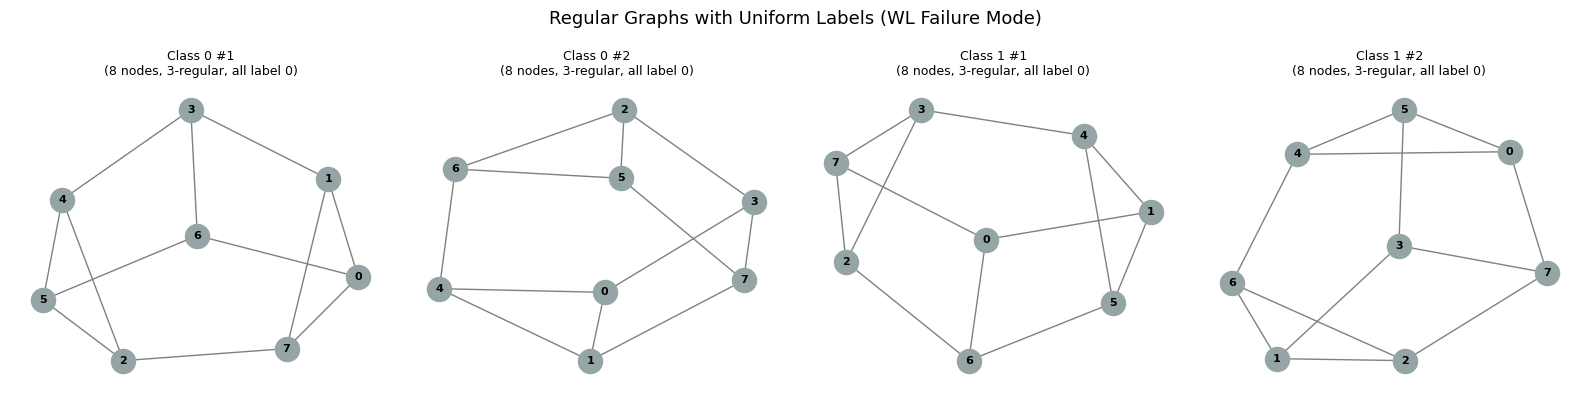

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for idx, (ax, G, title) in enumerate(zip(
    axes,
    [class0_reg[0], class0_reg[1], class1_reg[0], class1_reg[1]],
    ['Class 0 #1', 'Class 0 #2', 'Class 1 #1', 'Class 1 #2']
)):
    pos = nx.spring_layout(G, seed=42 + idx)
    nx.draw(G, pos, ax=ax, node_color='#95a5a6', with_labels=True,
            node_size=300, font_size=8, font_weight='bold', edge_color='gray')
    ax.set_title(title + f'\n(8 nodes, 3-regular, all label 0)', fontsize=9)

plt.suptitle('Regular Graphs with Uniform Labels (WL Failure Mode)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'failure_mode_examples.png'), dpi=150, bbox_inches='tight')
plt.show()

## Run WL Kernel on Failure Case

In [4]:
# Convert to our graph format
failure_graphs = []
for G in all_reg_graphs:
    failure_graphs.append({
        'adj_list': list(G.edges()),
        'node_labels': {v: G.nodes[v]['label'] for v in G.nodes()},
        'n_nodes': G.number_of_nodes(),
        'n_edges': G.number_of_edges()
    })

# WL features function
def wl_subtree_features(graphs, h=3, use_label_prefix=True):
    adj_lists = []
    current_labels = []
    for g in graphs:
        adj = defaultdict(list)
        for u, v in g['adj_list']:
            adj[u].append(v)
            adj[v].append(u)
        adj_lists.append(adj)
        current_labels.append(dict(g['node_labels']))
    
    label_counter = 0
    label_lookup = {}
    for g_labels in current_labels:
        for v, lbl in g_labels.items():
            s = str(lbl)
            if s not in label_lookup:
                label_lookup[s] = label_counter
                label_counter += 1
            g_labels[v] = label_lookup[s]
    
    feature_counts = [defaultdict(int) for _ in range(len(graphs))]
    for gi, g_labels in enumerate(current_labels):
        for v, lbl in g_labels.items():
            feature_counts[gi][lbl] += 1
    
    for iteration in range(1, h + 1):
        new_labels_all = []
        for gi, (adj, g_labels) in enumerate(zip(adj_lists, current_labels)):
            new_labels = {}
            for v in range(graphs[gi]['n_nodes']):
                neighbor_labels = sorted([g_labels[u] for u in adj[v]])
                if use_label_prefix:
                    label_string = str(g_labels[v]) + '_' + '_'.join(map(str, neighbor_labels))
                else:
                    label_string = '_'.join(map(str, neighbor_labels))
                if label_string not in label_lookup:
                    label_lookup[label_string] = label_counter
                    label_counter += 1
                new_labels[v] = label_lookup[label_string]
            new_labels_all.append(new_labels)
            for v, lbl in new_labels.items():
                feature_counts[gi][lbl] += 1
        current_labels = new_labels_all
    
    n_features = label_counter
    X = np.zeros((len(graphs), n_features))
    for gi, counts in enumerate(feature_counts):
        for lbl, cnt in counts.items():
            X[gi, lbl] = cnt
    return X, label_lookup

# Compute features
X_fail, label_map_fail = wl_subtree_features(failure_graphs, h=5)
print(f"Feature matrix shape: {X_fail.shape}")
print(f"Number of unique features: {X_fail.shape[1]}")

# Check if all feature vectors are identical
unique_rows = np.unique(X_fail, axis=0)
print(f"\nNumber of unique feature vectors: {unique_rows.shape[0]} (out of {X_fail.shape[0]} graphs)")
print("All graphs produce identical feature vectors!" if unique_rows.shape[0] == 1 else 
      f"There are {unique_rows.shape[0]} distinct feature vectors.")

Feature matrix shape: (100, 6)
Number of unique features: 6

Number of unique feature vectors: 1 (out of 100 graphs)
All graphs produce identical feature vectors!


In [5]:
# Compute kernel matrix
K_fail = X_fail @ X_fail.T

# Classification attempt
def classify_with_svm(K, y, n_folds=10, seed=42):
    C_values = [10**i for i in range(-3, 4)]
    cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    fold_accuracies = []
    for train_idx, test_idx in cv.split(np.zeros(len(y)), y):
        K_train = K[np.ix_(train_idx, train_idx)]
        K_test = K[np.ix_(test_idx, train_idx)]
        y_train, y_test = y[train_idx], y[test_idx]
        best_C, best_inner_acc = C_values[0], 0
        inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        for C in C_values:
            svm = SVC(kernel='precomputed', C=C)
            inner_scores = cross_val_score(svm, K_train, y_train, cv=inner_cv)
            if inner_scores.mean() > best_inner_acc:
                best_inner_acc = inner_scores.mean()
                best_C = C
        svm = SVC(kernel='precomputed', C=best_C)
        svm.fit(K_train, y_train)
        fold_accuracies.append(svm.score(K_test, y_test))
    return np.mean(fold_accuracies), np.std(fold_accuracies), fold_accuracies

acc_fail, std_fail, _ = classify_with_svm(K_fail, y_reg)
print(f"\nWL Kernel Accuracy on Regular Graphs: {acc_fail*100:.2f}% (+/- {std_fail*100:.2f}%)")
print(f"Expected for random guessing (balanced classes): ~50%")
print(f"The WL kernel CANNOT discriminate between these graph classes.")


WL Kernel Accuracy on Regular Graphs: 50.00% (+/- 0.00%)
Expected for random guessing (balanced classes): ~50%
The WL kernel CANNOT discriminate between these graph classes.


## Kernel Matrix Heatmap

The kernel matrix should show **no discrimination** between classes — all entries should be approximately equal, since all graphs produce the same feature vector.

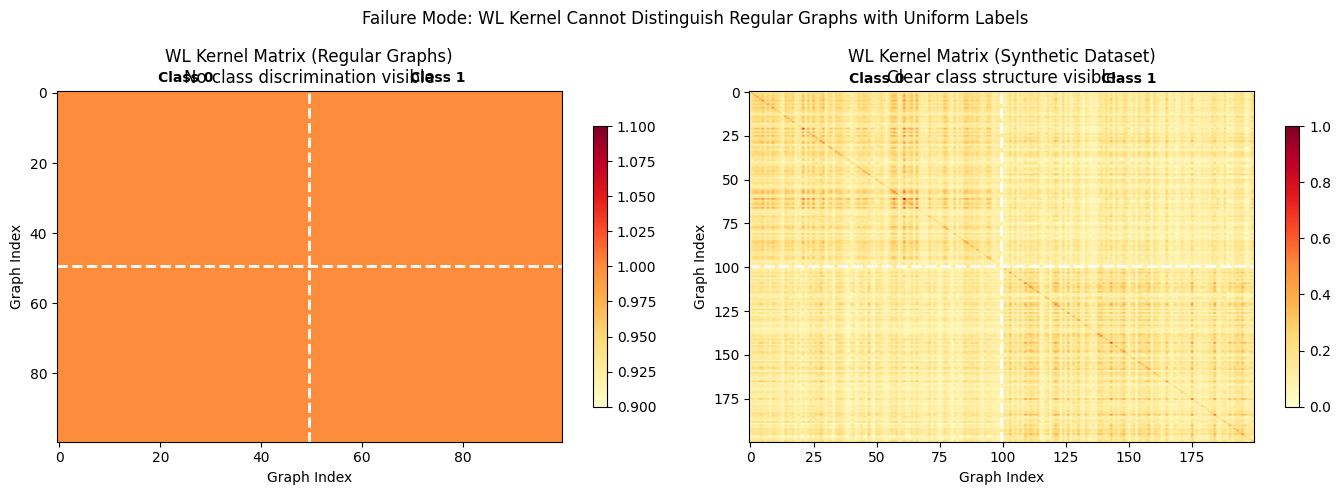

Saved to partB/results/failure_mode_heatmap.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normalize kernel matrix for visualization
K_norm = K_fail / np.max(K_fail) if np.max(K_fail) > 0 else K_fail

# Full heatmap
ax = axes[0]
im = ax.imshow(K_norm, cmap='YlOrRd', aspect='auto')
ax.axhline(y=49.5, color='white', linewidth=2, linestyle='--')
ax.axvline(x=49.5, color='white', linewidth=2, linestyle='--')
ax.set_xlabel('Graph Index')
ax.set_ylabel('Graph Index')
ax.set_title('WL Kernel Matrix (Regular Graphs)\nNo class discrimination visible')
ax.text(25, -3, 'Class 0', ha='center', fontweight='bold')
ax.text(75, -3, 'Class 1', ha='center', fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8)

# Compare with the successful case: load original results
import pickle
with open(os.path.join(results_dir, 'wl_results.pkl'), 'rb') as f:
    orig_results = pickle.load(f)
K_orig = orig_results['kernel_matrix']
K_orig_norm = K_orig / np.max(K_orig) if np.max(K_orig) > 0 else K_orig

ax = axes[1]
im = ax.imshow(K_orig_norm, cmap='YlOrRd', aspect='auto')
ax.axhline(y=99.5, color='white', linewidth=2, linestyle='--')
ax.axvline(x=99.5, color='white', linewidth=2, linestyle='--')
ax.set_xlabel('Graph Index')
ax.set_ylabel('Graph Index')
ax.set_title('WL Kernel Matrix (Synthetic Dataset)\nClear class structure visible')
ax.text(50, -5, 'Class 0', ha='center', fontweight='bold')
ax.text(150, -5, 'Class 1', ha='center', fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Failure Mode: WL Kernel Cannot Distinguish Regular Graphs with Uniform Labels', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'failure_mode_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved to partB/results/failure_mode_heatmap.png")

## Connection to Task 1.2 (Assumption 3)

This failure mode directly demonstrates **Assumption 3** from Task 1.2: the WL subtree kernel can only distinguish graphs that the 1-dimensional WL test can distinguish.

In $k$-regular graphs with uniform labels:
- Every node has the same degree $k$ and the same initial label
- After WL iteration 1, every node aggregates the same multiset of neighbor labels → same compressed label
- This pattern persists across all subsequent iterations
- **All graphs of the same size and degree produce identical feature vectors**

The paper acknowledges this limitation by referencing Cai, Fürer, and Immerman (1992), who showed that there exist families of non-isomorphic graphs that the 1-dimensional WL test cannot distinguish. Our experiment concretely demonstrates this: structurally different 3-regular graphs on 8 nodes are completely indistinguishable to the WL kernel.

## Suggested Fix

To overcome this limitation, one could:

1. **Use higher-dimensional WL tests** ($k$-WL for $k > 1$): Consider tuples of $k$ nodes instead of individual nodes, capturing higher-order structural patterns at the cost of increased complexity ($O(n^k)$ per iteration).

2. **Incorporate additional structural features**: Augment the WL feature vector with node-level structural descriptors such as:
   - Local clustering coefficients
   - Betweenness centrality
   - Spectral features (eigenvalues of the adjacency/Laplacian matrix)
   - Graphlet counts

3. **Use continuous WL variants**: Replace discrete label hashing with continuous message-passing (as in Graph Neural Networks), which can learn to distinguish graphs that the discrete WL test cannot.